# Del catastro al lote

Baja los lotes catastrales del IGAC de las grillas seleccionadas (lo que el catastro llama
predios: unidades continuas con un número predial y un mismo titular), mide cada uno y
los caracteriza. La lógica vive en los módulos de `predios/`; este cuaderno los invoca,
comprueba lo que devuelven y sirve para explorar el resultado.

| Módulo | Qué resuelve |
|---|---|
| `predios_igac.py` | descarga y caché del catastro para cualquier conjunto de grillas |
| `terreno.py` | pendiente, rugosidad y cobertura medidas dentro de cada lote |
| `lotes.py` | criterios de discriminación, puntuación y clasificación por perfil |
| `juridico.py`, `valor.py`, `entorno.py`, `pot.py` | UAF y restitución, valor de referencia, entorno ambiental y minero, norma urbana |

**Fuentes.** Base Catastral Pública del IGAC (corte 31 de enero de 2026, FeatureServer),
Copernicus DEM GLO-30, ESA WorldCover 2021, OpenStreetMap para vías, UPME (capacidad de
barra, Circular 054 de 2026), ANT, URT, IGAC (zonas geoeconómicas y POT LADM-COL), IDEAM,
MADS, UPRA, ANM, ANH, SGC.

Método y justificación de cada decisión: `docs/PREDIOS.md`.

## 1. Preparación

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Los módulos viven en paquetes; se añaden al path para que funcione desde cualquier directorio.
_raiz = Path.cwd() if (Path.cwd() / "reporte").is_dir() else Path.cwd().parent
sys.path[:0] = [str(_raiz), str(_raiz / "soporte"), str(_raiz / "predios")]

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import predios_igac as pig
import reporte.datos as rg
import terreno
import lotes

print("raíz del proyecto :", _raiz)
print("capas del IGAC    :", pig.CAPAS, "+ REGISTRO_1 (tabla", pig.CAPA_REGISTRO, ")")
print("página            :", pig.PAGINA, "registros por petición")
print("criterios índice  :", list(rg.CRITERIOS))
for nombre, perfil in rg.PERFILES.items():
    print(f"  perfil {nombre:<13} {perfil['ha_proyecto']:>6.0f} ha · {perfil['mw_proyecto']:>4.0f} MW")

raíz del proyecto : C:\Users\samue\Documents\Work\MMC\prospectos-solares
capas del IGAC    : {14: 'rural', 7: 'urbano'} + REGISTRO_1 (tabla 17 )
página            : 1000 registros por petición
criterios índice  : ['dist_sub', 'cobertura', 'pendiente', 'recurso', 'rugosidad', 'capacidad', 'dist_via']
  perfil utility          150 ha ·   50 MW
  perfil distribuida        2 ha ·    2 MW


## 2. Qué grillas se trabajan  ← AQUÍ SE INDICA EL INSUMO

Grilla y celda son lo mismo: cada cuadrado de 5 × 5 km del modelo. Este cuaderno busca
predios **dentro de las grillas que se le indiquen**, y nada en el código conoce ninguna
en concreto. Si mañana el modelo devuelve otras cien, no hay nada que tocar.

**Cómo pasarle una selección hecha en el reporte de grillas:**

1. En el reporte de grillas, marca las que quieras explorar y usa el botón de descarga
   (sale `grillas_para_predios.geojson` o `.csv`, los dos sirven).
2. Guarda ese archivo dentro de la carpeta del proyecto, por ejemplo en `outputs/reporte/`.
3. En la casilla de abajo escribe su ruta en `CELDAS`, así:

```python
CELDAS = "outputs/reporte/grillas_para_predios.geojson"
```

Da igual si son 5, 10 o 40 grillas. Las otras dos formas de indicarlas siguen valiendo:
`None` trabaja las cien del reporte, y una lista de códigos separada por comas
(`"0011452,0010960"`) trabaja solo esas.

> Si tus grillas están entre las cien del reporte, sus predios ya están evaluados y no
> hace falta correr este cuaderno para verlas: basta con
> `python -m reporte_predios --grillas <tu archivo>`. Este cuaderno se corre cuando el
> modelo entrega grillas nuevas.

In [2]:
# ==========================================================================
#  ÚNICA LÍNEA QUE HAY QUE CAMBIAR PARA TRABAJAR OTRAS GRILLAS
# ==========================================================================
# Ruta del archivo que bajaste del reporte de grillas (GeoJSON o CSV), por ejemplo:
#     CELDAS = "outputs/reporte/grillas_para_predios.geojson"
# También vale None (las cien del reporte) o una lista de códigos: "0011452,0010960".
CELDAS = None

# Filtro opcional por clasificación de la grilla; "todas" no filtra nada.
CLASE = "todas"        # "Prioritaria", "Elegible", "Condicionada", "Excluida", "todas"

celdas = pig.resolver_celdas(CELDAS, CLASE)
print(f"{len(celdas)} grillas de {celdas.attrs.get('origen', '?')}, "
      f"{celdas['departamento'].nunique() if 'departamento' in celdas.columns else '?'} departamentos")
if "clasificacion" in celdas.columns:
    display(celdas["clasificacion"].value_counts().to_frame("grillas"))

100 grillas de grillas_candidatas.gpkg, 15 departamentos


,grillas
clasificacion,
Condicionada,61
Elegible,17
Excluida,12
Prioritaria,10


## 3. Descarga

`descargar_raw` guarda la respuesta del IGAC tal cual llega, una por grilla y capa, en
`data/igac/`; `descargar_registro` añade la tabla REGISTRO_1 (destino económico y área
construida); `procesar_celda` repara geometrías, deduplica, recorta a la grilla y une las
dos fuentes. El crudo es el insumo y se publica en el bucket; el recorte y las medidas se
recalculan. Un manifiesto en `data/igac/_estado.json` permite reintentar solo lo pendiente.

In [3]:
import insumos
recuperados = insumos.asegurar("igac_predios", verbose=True)
print(f"{recuperados} respuestas traídas del bucket")

falta = pig.pendientes(celdas)
print(f"{len(falta)} celdas sin descarga completa"
      + (f": {', '.join(falta[:8])}{'...' if len(falta) > 8 else ''}" if falta else ""))

0 respuestas traídas del bucket


0 celdas sin descarga completa


In [4]:
# Solo se consulta lo que falte; con todo en caché tarda segundos.
celdas_wgs = celdas.to_crs(config.CRS_GEOGRAFICO)
manifiesto = pig.leer_manifiesto()
fallos = []

for i, (_, fila) in enumerate(celdas_wgs.iterrows(), 1):
    cid = str(fila["cell_id"])
    if cid not in falta:
        continue
    try:
        pig.descargar_raw(cid, fila.geometry, manifiesto=manifiesto)
        pig.descargar_registro(cid, manifiesto=manifiesto)
        pig.descargar_registro(cid, manifiesto=manifiesto, tabla=pig.CAPA_REGISTRO2)
    except Exception as exc:
        print(f"  {cid}  error: {type(exc).__name__}: {str(exc)[:60]}")
        fallos.append(cid)
    pig.escribir_manifiesto(manifiesto)

print("celdas con error:", ", ".join(fallos) or "ninguna")
print("pendientes tras la corrida:", len(pig.pendientes(celdas)))

celdas con error: ninguna


pendientes tras la corrida: 0


In [5]:
predios = lotes.cargar_predios(celdas)
predios = lotes.asignar_celda_unica(predios, celdas)
print(f"{len(predios):,} predios de {predios['cell_id'].nunique()} celdas".replace(",", "."))
predios[["cell_id", "CODIGO", "clase_suelo", "destino", "area_ha",
         "compacidad", "ancho_util_m"]].head()

  predios: reutilizando predios.gpkg, cubre exactamente las 87 celdas con predios


  predios que cruzan el lindero de la grilla: 480 copias retiradas, cada una se queda en la celda con la que más superficie comparte
22.658 predios de 85 celdas


,cell_id,CODIGO,clase_suelo,destino,area_ha,compacidad,ancho_util_m
0,0012960,084360002000000010010000000000,rural,agropecuario,203.53,0.394,751.6
1,0012960,084360002000000010035000000000,rural,agropecuario,77.45,0.516,637.1
2,0012960,081410001000000000129000000000,rural,agropecuario,70.25,0.675,628.0
3,0012960,084360002000000010043000000000,rural,agropecuario,54.69,0.652,603.4
4,0012960,084360002000000010003000000000,rural,agropecuario,51.70,0.476,496.0


## 4. Comprobaciones

Seis controles de calidad sobre lo descargado: truncamiento por página, validez y
duplicados, cobertura de la ficha alfanumérica, densidad de vértices, solape y hueco
catastral por grilla, y área en hectáreas.

In [6]:
# a) truncamiento: una grilla con un múltiplo exacto de la página es sospechosa
por_celda = predios.groupby("cell_id").size().sort_values(ascending=False)
print("Predios por celda, las cinco mayores:")
print(por_celda.head())
sospechosas = por_celda[por_celda % pig.PAGINA == 0]
print("\nCeldas con múltiplo exacto de la página (posible truncamiento):",
      list(sospechosas.index) or "ninguna")

# b) validez y duplicados
m = predios.to_crs(config.CRS_METRICO)
print("\nGeometrías inválidas tras reparar :", int((~m.geometry.is_valid).sum()))
print("Códigos catastrales repetidos      :",
      int(predios.duplicated(subset=["CODIGO", "cell_id"]).sum()))
print("Predios en más de una celda        :",
      int((predios.groupby("CODIGO")["cell_id"].nunique() > 1).sum()),
      "  (ya resueltos: cada uno se queda en la celda con la que más comparte)")

# c) cobertura de la ficha alfanumérica
print("\nCon ficha REGISTRO_1               : "
      f"{predios['destino_economico'].notna().mean() * 100:.1f}%")
print("Destinos más frecuentes            :",
      predios["destino"].value_counts().head(4).to_dict())

# d) densidad de vértices
import shapely
nv = shapely.get_num_coordinates(predios.geometry.values)
print(f"\nVértices por predio                : mediana {int(np.median(nv))}, "
      f"p99 {int(np.percentile(nv, 99))}, máximo {nv.max():,}".replace(",", "."))
print(predios.assign(vertices=nv).nlargest(3, "vertices")
      [["cell_id", "CODIGO", "area_ha", "vertices"]].to_string(index=False))

Predios por celda, las cinco mayores:
cell_id
0022072    2952
0009399    2202
0011561    1566
0009070    1534
0011452    1163
dtype: int64

Celdas con múltiplo exacto de la página (posible truncamiento): ninguna



Geometrías inválidas tras reparar : 0
Códigos catastrales repetidos      : 0
Predios en más de una celda        : 0   (ya resueltos: cada uno se queda en la celda con la que más comparte)

Con ficha REGISTRO_1               : 98.0%
Destinos más frecuentes            : {'habitacional': 10066, 'agropecuario': 7682, 'agrícola': 2175, 'S': 936}

Vértices por predio                : mediana 11. p99 288. máximo 640.611
cell_id                         CODIGO  area_ha  vertices
0012453 131400001000000039001000000000  2441.01    640611
0011225 132440003000000033163300000000    26.97     32947
0011243 132220001000000000207000000000   273.93     23012


El máximo de vértices llega así del IGAC: un predio de Calamar concentra más de
seiscientos mil, unas cuatro mil veces la mediana, y cruza cuatro grillas. Por eso el
GeoJSON se exporta con seis decimales (unos 11 cm) y no con la precisión de máquina.

In [7]:
# e) solape entre predios y hueco sin catastrar, por grilla
cm = celdas.to_crs(config.CRS_METRICO).set_index(celdas["cell_id"].astype(str))
filas = []
for cid, sub in m.groupby(predios["cell_id"].astype(str).values):
    suma = sub.geometry.area.sum()
    union = sub.geometry.union_all()
    cg = cm.loc[cid].geometry
    filas.append({
        "cell_id": cid,
        "predios": len(sub),
        "solape_pct": round((suma - union.area) / suma * 100, 3) if suma else 0.0,
        "celda_catastrada_pct": round(union.intersection(cg).area / cg.area * 100, 1),
    })
calidad = pd.DataFrame(filas).sort_values("celda_catastrada_pct")
print("Solape entre predios de la misma celda, en %:")
print(calidad["solape_pct"].describe().round(3).to_string())
print("\nSuperficie de la celda cubierta por catastro, las diez peores:")
print(calidad.head(10).to_string(index=False))

Solape entre predios de la misma celda, en %:
count    85.000
mean      0.709
std       2.187
min       0.000
25%       0.000
50%       0.045
75%       0.396
max      17.547

Superficie de la celda cubierta por catastro, las diez peores:
cell_id  predios  solape_pct  celda_catastrada_pct
0029005        7       0.000                   3.2
0008868        9      -0.000                   3.7
0008869        7      -0.000                  12.1
0012960       70       0.044                  25.1
0010703       28      -0.000                  27.0
0010221       14      -0.000                  30.3
0011914        7       0.000                  34.1
0009784       15       0.000                  44.4
0007111      193       0.219                  54.4
0009997      101       1.086                  55.6


El solape entre predios es residual; el hueco no. En las grillas donde el catastro cubre
menos de la mitad de la superficie la selección describe solo la parte formalizada, y el
conteo de lotes no debe leerse como el total del territorio.

In [8]:
# f) área en hectáreas
print("Área de los predios, en hectáreas:")
print(predios["area_ha"].describe(percentiles=[.05, .25, .5, .75, .95]).round(2).to_string())

resumen = pd.DataFrame({
    "área mínima (ha)": [1, 2, 5, 10, 20, 50, 100, 150, 300],
})
resumen["MWp que admite"] = (resumen["área mínima (ha)"] / rg.HA_POR_MWP).round(0)
resumen["predios"] = [int((predios["area_ha"] >= c).sum()) for c in resumen["área mínima (ha)"]]
resumen["% del total"] = (resumen["predios"] / len(predios) * 100).round(1)
resumen

Área de los predios, en hectáreas:
count    22658.00
mean        12.90
std         56.67
min          0.00
5%           0.01
25%          0.01
50%          0.06
75%          5.69
95%         56.23
max       2441.01


,área mínima (ha),MWp que admite,predios,% del total
0,1,1.0,7988,35.3
1,2,1.0,7382,32.6
2,5,3.0,5962,26.3
3,10,7.0,4248,18.7
4,20,13.0,2699,11.9
5,50,33.0,1264,5.6
6,100,67.0,620,2.7
7,150,100.0,378,1.7
8,300,200.0,158,0.7


### El área se mide en CRS métrico

Sobre coordenadas geográficas `.area` devuelve grados cuadrados. El área es el primer
filtro de todos los criterios, así que se reproyecta a UTM 18N antes de medir.

In [9]:
uno = predios.iloc[[0]]
mal = uno.geometry.area.iloc[0]                                   # en grados, sin sentido
bien = uno.to_crs(config.CRS_METRICO).geometry.area.iloc[0] / 10_000

print(f"Predio {uno['CODIGO'].iloc[0]} de la celda {uno['cell_id'].iloc[0]}")
print(f"  .area sobre coordenadas en grados : {mal:.10f}   (no son metros ni nada)")
print(f"  reproyectando a UTM 18N           : {bien:,.2f} ha".replace(",", "."))

Predio 084360002000000010010000000000 de la celda 0012960
  .area sobre coordenadas en grados : 0.0001682272   (no son metros ni nada)
  reproyectando a UTM 18N           : 203.53 ha


## 5. El terreno, medido dentro del predio

El panel trae pendiente y cobertura agregadas a la grilla de 5 × 5 km; para elegir lote
hace falta el valor de cada predio. `terreno.py` lee por ventana el Copernicus DEM (30 m)
y el WorldCover (10 m), recorta a la grilla y calcula la estadística de cada polígono.
Lectura remota sin credenciales; recortes cacheados en `data/dem/` y `data/cobertura/`.

In [10]:
predios = lotes.añadir_forma(predios)
predios = lotes.añadir_terreno(predios, celdas)

comparacion = (predios.groupby("cell_id")
               .agg(predios=("area_ha", "size"),
                    pend_min=("pendiente_media", "min"),
                    pend_mediana=("pendiente_media", "median"),
                    pend_max=("pendiente_media", "max"),
                    cob_min=("cobertura_apta_pct", "min"),
                    cob_max=("cobertura_apta_pct", "max")))
celda_panel = celdas.set_index(celdas["cell_id"].astype(str))
comparacion["pend_panel"] = celda_panel["slope_mean"].round(2)
comparacion["cob_panel"] = celda_panel["cobertura_apta_pct"].round(1)
print("Pendiente y cobertura: lo que dice el panel de la celda contra lo que hay dentro")
comparacion.round(1).head(12)

  terreno: 13358 de 22658 predios con pendiente y cobertura propias (9300 demasiado pequeños para un píxel de 30 m)
Pendiente y cobertura: lo que dice el panel de la celda contra lo que hay dentro


,predios,pend_min,pend_mediana,pend_max,cob_min,cob_max,pend_panel,cob_panel
cell_id,,,,,,,,
0006710,168,0.2,3.4,18.6,0.0,100.0,10.2,65.3
0006910,38,1.2,14.2,23.4,3.7,90.9,11.3,60.2
0007111,193,0.6,3.8,14.9,0.0,100.0,9.6,63.4
0007112,34,2.4,12.0,18.8,0.0,81.7,11.2,51.9
0007316,342,0.3,5.4,21.6,0.0,100.0,11.1,55.6
0008677,253,1.7,9.3,20.6,0.0,100.0,8.9,65.9
0008868,9,3.3,5.6,15.4,25.4,98.7,3.8,84.1
0008869,7,5.7,7.3,11.8,15.6,92.2,4.5,80.4
0008889,306,1.4,5.0,30.3,0.0,100.0,5.4,75.4


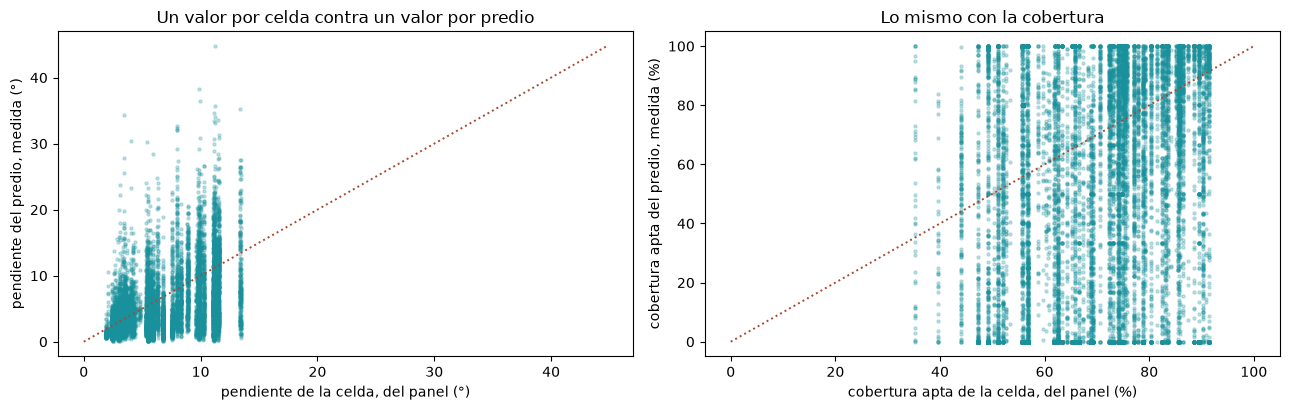

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

d = predios.dropna(subset=["pendiente_media"])
ax[0].scatter(d["cell_id"].map(celda_panel["slope_mean"]), d["pendiente_media"],
              s=5, alpha=.25, color="#18919C")
lim = [0, max(1, d["pendiente_media"].max())]
ax[0].plot(lim, lim, color="#A8492F", ls=":", lw=1.4)
ax[0].set_xlabel("pendiente de la celda, del panel (°)")
ax[0].set_ylabel("pendiente del predio, medida (°)")
ax[0].set_title("Un valor por celda contra un valor por predio")

d2 = predios.dropna(subset=["cobertura_apta_pct"])
ax[1].scatter(d2["cell_id"].map(celda_panel["cobertura_apta_pct"]),
              d2["cobertura_apta_pct"], s=5, alpha=.25, color="#18919C")
ax[1].plot([0, 100], [0, 100], color="#A8492F", ls=":", lw=1.4)
ax[1].set_xlabel("cobertura apta de la celda, del panel (%)")
ax[1].set_ylabel("cobertura apta del predio, medida (%)")
ax[1].set_title("Lo mismo con la cobertura")

plt.tight_layout(); plt.show()

Para una misma grilla, sus predios se reparten a lo largo de todo el eje: el valor de la
grilla no describe al predio.

## 6. Los criterios de discriminación

Cuatro bloques en orden: primero se descarta y solo sobre lo que sobrevive se puntúa.

- **Excluyentes.** Grilla excluida, suelo urbano, destino económico habitacional. La
  Ley 2ª se informa pero ya no excluye; la lee el POT del lote.
- **Tamaño y forma.** Se miden área útil (núcleo a 30 m × cobertura apta × pendiente) y
  ancho útil, pero **el tamaño no descarta**: el área que busca el proyecto la define el
  usuario en el visor. Se anota si el predio cabe cada perfil (`cabe_utility`,
  `cabe_distribuida`) y solo se aparta como "Pequeño" el que no llega a 2 ha brutas
  (`HA_MINIMA_CARACTERIZAR`, `--ha-minima`).
- **Puntuación.** Los criterios y umbrales del reporte de grillas con los valores medidos
  en el predio, para que el índice de lote y el de grilla signifiquen lo mismo.
- **Segunda criba** tras consultar entorno y POT: título minero vigente excluye; suelo de
  protección dominante según el POT baja a Con reparos.

De las tres medidas de forma que se calculan solo el ancho útil tiene sentido como
filtro; `--justificar` lo muestra frente a los tamaños de referencia de cada perfil.

In [12]:
predios = lotes.añadir_ley2(predios)
predios = lotes.añadir_dist_via(predios)
predios = lotes.añadir_area_util(predios)

for perfil, cfg in rg.PERFILES.items():
    print("=" * 74)
    print(f"CORTES DE FORMA, perfil {perfil}  ({cfg['ha_proyecto']:.0f} ha)")
    print("=" * 74)
    lotes.justificar(predios, cfg["ha_proyecto"])
    print()

  Reserva Forestal de Ley 2ª de 1959


     del bucket gs://prospectos_solares/insumos/restricciones/ley2.geojson


  Ley 2ª: 0 predios tocados, 0 por encima del 10% que descarta
    (ninguna celda con predios descargados toca la reserva)


  vías: 22658 de 22658 predios medidos desde el lindero. Mediana 0.166 km; 39% dentro del tope de 0.1 km y 6% pasado el límite de 1.5 km, así que el criterio casi no separa
CORTES DE FORMA, perfil utility  (150 ha)

  Sobre los 378 predios que ya alcanzan 150 ha brutas:
       compacidad  ancho_util_m  nucleo_frac
count     378.000       378.000      378.000
mean        0.431      1243.904        0.901
std         0.155       395.595        0.029
min         0.003       491.000        0.738
5%          0.181       750.820        0.851
10%         0.218       831.420        0.864
25%         0.315       977.225        0.885
50%         0.442      1162.000        0.905
75%         0.538      1410.300        0.920
max         0.794      3037.700        0.954

  Correlación entre las tres medidas de forma:
              compacidad  ancho_util_m  nucleo_frac
compacidad          1.00          0.18         0.55
ancho_util_m        0.18          1.00         0.76
nucleo_frac         0.55      

Lectura de la salida (perfil utility, 378 lotes de 150 ha o más):

- **La compacidad de Polsby-Popper no sirve como filtro.** Un corte en 0,30 dejaría fuera
  80 lotes (21%) y su correlación con el ancho es 0,18: penaliza el lindero dentado, no la
  forma inservible. Se conserva como descriptor.
- **El ancho (mayor círculo inscrito) sí describe la forma inservible**: es la medida que
  ataca la cinta larga y estrecha, y por eso es la que se ofrece como filtro en el visor.
- **El área de núcleo no es un criterio aparte**: solo interviene en la estimación auxiliar
  `area_util_ha`, que no se muestra ni filtra.

## 7. Selección

Los dos perfiles en la misma corrida; entre ellos cambian el rango de tensión del punto
de conexión, la capacidad de barra que se puntúa y el tamaño de referencia (que ya no
criba). Por perfil salen `lotes_<perfil>.csv` y `.geojson` con todos los predios
caracterizados (≥ 2 ha brutas, no excluidos; para QGIS y para el visor), y
`lotes_<perfil>_descartados.csv` con Pequeños, No aptos y Excluidos y su motivo, sin
geometría: son decenas de miles de polígonos.

In [13]:
seleccion = {}
for perfil in rg.PERFILES:
    q = lotes.procesar(perfil, predios, celdas)
    lotes.exportar(q, perfil)
    lotes.resumen(q, perfil)
    seleccion[perfil] = q
    print()


  Perfil utility: Escala utility, 10 MW o más, 150 ha, ancho mínimo 387 m


  conexión: 477 subestaciones en 58-230 kV, mediana al lindero 13.9 km


  cribado jurídico: 1754 de 22658 lotes superan la UAF máxima de su municipio; 14152 están en municipio con microzona de restitución


  CSV     -> C:\Users\samue\Documents\Work\MMC\prospectos-solares\outputs\reporte\lotes_utility.csv  (152 lotes)
  GeoJSON -> C:\Users\samue\Documents\Work\MMC\prospectos-solares\outputs\reporte\lotes_utility.geojson
  descartes con su motivo -> lotes_utility_descartados.csv (22506 predios, sin geometría)

--------------------------------------------------------------------------
RESULTADO  ·  perfil utility
--------------------------------------------------------------------------
clasificacion
Idóneo            67
Viable            10
Con reparos       75
No apto         9960
Excluido       12546

  lotes que pasan tamaño y forma : 152
  celdas con al menos un lote    : 49 de 85
  MWp indicativos acumulados     : 29.688

  Los diez primeros:
 orden cell_id         municipio clasificacion  indice_lote  area_util_ha  mwp_lote  pendiente_media  cobertura_apta_pct  dist_via_km  conexion_km
     1 0010222       Montelíbano        Idóneo         85.3        246.62     164.4             2.6

  conexión: 373 subestaciones en 58-115 kV, mediana al lindero 13.9 km


  cribado jurídico: 1754 de 22658 lotes superan la UAF máxima de su municipio; 14152 están en municipio con microzona de restitución


  CSV     -> C:\Users\samue\Documents\Work\MMC\prospectos-solares\outputs\reporte\lotes_distribuida.csv  (3943 lotes)
  GeoJSON -> C:\Users\samue\Documents\Work\MMC\prospectos-solares\outputs\reporte\lotes_distribuida.geojson
  descartes con su motivo -> lotes_distribuida_descartados.csv (18715 predios, sin geometría)

--------------------------------------------------------------------------
RESULTADO  ·  perfil distribuida
--------------------------------------------------------------------------
clasificacion
Idóneo          2836
Viable           263
Con reparos      844
No apto         6169
Excluido       12546

  lotes que pasan tamaño y forma : 3943
  celdas con al menos un lote    : 79 de 85
  MWp indicativos acumulados     : 73.002

  Los diez primeros:
 orden cell_id  municipio clasificacion  indice_lote  area_util_ha  mwp_lote  pendiente_media  cobertura_apta_pct  dist_via_km  conexion_km
     1 0012074      Guamo        Idóneo         96.1          7.40       4.9            

In [14]:
tabla = pd.DataFrame({
    perfil: q["clasificacion"].value_counts() for perfil, q in seleccion.items()
}).reindex(list(lotes.ORDEN)).fillna(0).astype(int)
tabla.loc["TOTAL"] = tabla.sum()
tabla

,utility,distribuida
clasificacion,,
Idóneo,67,2836
Viable,10,263
Con reparos,75,844
No apto,9960,6169
Excluido,12546,12546
TOTAL,22658,22658


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

grandes = predios[predios["area_ha"].between(1, 500)]
ax[0].hist(grandes["area_ha"], bins=60, color="#18919C", edgecolor="white", linewidth=.4)
for ha, txt in [(rg.PERFILES["distribuida"]["ha_proyecto"], "distribuida"),
                (rg.PERFILES["utility"]["ha_proyecto"], "utility")]:
    ax[0].axvline(ha, color="#A8492F", ls=":", lw=1.4)
    ax[0].text(ha, ax[0].get_ylim()[1] * .9, f" {txt}", fontsize=8, color="#A8492F")
ax[0].set_title("Área de los lotes, de 1 a 500 ha")
ax[0].set_xlabel("hectáreas"); ax[0].set_ylabel("lotes")

ax[1].scatter(predios["area_ha"], predios["ancho_util_m"], s=6, alpha=.3, color="#18919C")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_title("Área frente a ancho (mayor círculo inscrito)")
ax[1].set_xlabel("hectáreas"); ax[1].set_ylabel("diámetro del mayor círculo inscrito (m)")

u = seleccion["utility"]
apto = u["clasificacion"].isin(lotes.SELECCIONABLES)
ax[2].scatter(u.loc[~apto, "area_ha"], u.loc[~apto, "indice_lote"],
              s=6, alpha=.2, color="#B9B9B9", label="pequeño o excluido")
ax[2].scatter(u.loc[apto, "area_ha"], u.loc[apto, "indice_lote"],
              s=14, alpha=.8, color="#18919C", label="lote caracterizado")
ax[2].axhline(rg.INDICE_PRIORITARIA, color="#A8492F", ls=":", lw=1.4)
ax[2].set_xscale("log")
ax[2].set_title("Perfil utility: área del lote frente a índice")
ax[2].set_xlabel("hectáreas"); ax[2].set_ylabel("índice del lote")
ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [ ]:
mejores = seleccion["utility"].query("clasificacion in ['Idóneo', 'Viable']").head(15)
mejores[["orden", "cell_id", "departamento", "municipio", "CODIGO", "destino",
         "area_ha", "cobertura_apta_pct", "mwp_lote", "pendiente_media",
         "dist_via_km", "conexion_km", "indice_lote"]]

## 8. Qué queda fuera

- **El propietario.** El FeatureServer del IGAC no entrega el titular; sale del
  certificado de tradición de la SNR, que se obtiene con la matrícula. Ver
  `predios/registro.py`, `predios/certificados.py` y `docs/ADQUISICION.md`.
- **Los usos prohibidos del POT.** `predios/pot.py` trae la categoría del suelo, su
  reparto de área y la clasificación desde los geoservicios LADM-COL del IGAC (761
  municipios), pero los usos prohibidos y condicionados casi no están publicados por
  máquina; el certificado de uso del suelo lo expide la alcaldía.
- **El relieve bajo el bosque.** El Copernicus DEM es un modelo de superficie: sobre
  bosque cerrado mide la copa. La cobertura arbolada ya descuenta esos predios.
- **El catastro que no existe.** Grillas con menos de la mitad de su superficie
  catastrada; ahí no faltan lotes, falta formalización.